100%|██████████| 26.4M/26.4M [00:01<00:00, 15.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 264kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 8.97MB/s]


Epoch [1/15] Loss: 0.0406
Epoch [2/15] Loss: 0.0169
Epoch [3/15] Loss: 0.0141
Epoch [4/15] Loss: 0.0128
Epoch [5/15] Loss: 0.0120
Epoch [6/15] Loss: 0.0114
Epoch [7/15] Loss: 0.0110
Epoch [8/15] Loss: 0.0107
Epoch [9/15] Loss: 0.0105
Epoch [10/15] Loss: 0.0103
Epoch [11/15] Loss: 0.0102
Epoch [12/15] Loss: 0.0101
Epoch [13/15] Loss: 0.0100
Epoch [14/15] Loss: 0.0099
Epoch [15/15] Loss: 0.0098


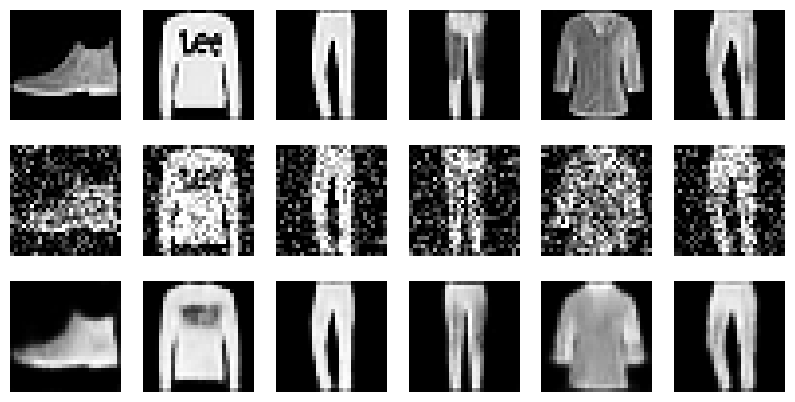

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ===============================
# Device configuration
# ===============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===============================
# Hyperparameters
# ===============================
batch_size = 128
learning_rate = 0.001
epochs = 15
noise_factor = 0.3

# ===============================
# Dataset
# ===============================
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data",
    train=False,
    transform=transform,
    download=True
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# ===============================
# Gaussian Noise Function
# ===============================
def add_noise(images, noise_factor):

    noise = torch.randn_like(images) * noise_factor
    noisy_images = images + noise
    noisy_images = torch.clamp(noisy_images, 0., 1.)

    return noisy_images

# ===============================
# Autoencoder Model
# ===============================
class DenoisingAutoencoder(nn.Module):

    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(

            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=7)
        )

        # Decoder
        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(64, 32, kernel_size=7),
            nn.ReLU(),

            nn.ConvTranspose2d(
                32, 16, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                16, 1, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):

        x = self.encoder(x)
        x = self.decoder(x)

        return x


model = DenoisingAutoencoder().to(device)

# ===============================
# Loss and Optimizer
# ===============================
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# ===============================
# Training Loop
# ===============================
for epoch in range(epochs):

    total_loss = 0

    for images, _ in train_loader:

        images = images.to(device)

        noisy_images = add_noise(images, noise_factor)

        outputs = model(noisy_images)

        loss = criterion(outputs, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {total_loss/len(train_loader):.4f}")

# ===============================
# Visualization Function
# ===============================
def show_images(original, noisy, reconstructed):

    original = original.cpu().detach()
    noisy = noisy.cpu().detach()
    reconstructed = reconstructed.cpu().detach()

    fig, axes = plt.subplots(3, 6, figsize=(10,5))

    for i in range(6):

        axes[0,i].imshow(original[i].squeeze(), cmap="gray")
        axes[0,i].axis("off")

        axes[1,i].imshow(noisy[i].squeeze(), cmap="gray")
        axes[1,i].axis("off")

        axes[2,i].imshow(reconstructed[i].squeeze(), cmap="gray")
        axes[2,i].axis("off")

    axes[0,0].set_ylabel("Original")
    axes[1,0].set_ylabel("Noisy")
    axes[2,0].set_ylabel("Reconstructed")

    plt.show()

# ===============================
# Evaluation
# ===============================
model.eval()

with torch.no_grad():

    images, _ = next(iter(test_loader))
    images = images.to(device)

    noisy_images = add_noise(images, noise_factor)

    reconstructed = model(noisy_images)

show_images(images, noisy_images, reconstructed)